# EDA PPG SBP/DBP

## Импорт библиотек

In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path(r"D:\datasets\PulseDB")

files = [
    "VitalDB_Train_Subset.mat",
    "VitalDB_CalBased_Test_Subset.mat",
    "VitalDB_CalFree_Test_Subset.mat",
    "VitalDB_AAMI_Test_Subset.mat",
    "VitalDB_AAMI_Cal_Subset.mat",
]

mat_files = [DATA_DIR / f for f in files if (DATA_DIR / f).exists()]
mat_files

[WindowsPath('D:/datasets/PulseDB/VitalDB_Train_Subset.mat'),
 WindowsPath('D:/datasets/PulseDB/VitalDB_CalBased_Test_Subset.mat'),
 WindowsPath('D:/datasets/PulseDB/VitalDB_CalFree_Test_Subset.mat'),
 WindowsPath('D:/datasets/PulseDB/VitalDB_AAMI_Test_Subset.mat'),
 WindowsPath('D:/datasets/PulseDB/VitalDB_AAMI_Cal_Subset.mat')]

## Загрузка датасета для анализа

In [2]:
for path in mat_files:
    print("\n===", path.name, "===")
    with h5py.File(path, "r") as f:
        subset = f["Subset"]
        for key in subset.keys():
            obj = subset[key]
            print(key, "shape:", obj.shape, "dtype:", obj.dtype)


=== VitalDB_Train_Subset.mat ===
Age shape: (1, 465480) dtype: float64
BMI shape: (1, 465480) dtype: float64
DBP shape: (1, 465480) dtype: float64
Gender shape: (1, 465480) dtype: object
Height shape: (1, 465480) dtype: float64
SBP shape: (1, 465480) dtype: float64
Signals shape: (1250, 3, 465480) dtype: float64
Subject shape: (1, 465480) dtype: object
Weight shape: (1, 465480) dtype: float64

=== VitalDB_CalBased_Test_Subset.mat ===
Age shape: (1, 51720) dtype: float64
BMI shape: (1, 51720) dtype: float64
DBP shape: (1, 51720) dtype: float64
Gender shape: (1, 51720) dtype: object
Height shape: (1, 51720) dtype: float64
SBP shape: (1, 51720) dtype: float64
Signals shape: (1250, 3, 51720) dtype: float64
Subject shape: (1, 51720) dtype: object
Weight shape: (1, 51720) dtype: float64

=== VitalDB_CalFree_Test_Subset.mat ===
Age shape: (1, 57600) dtype: float64
BMI shape: (1, 57600) dtype: float64
DBP shape: (1, 57600) dtype: float64
Gender shape: (1, 57600) dtype: object
Height shape: (1

## Извлечение демографий пациентов

In [3]:
def decode_matlab_string(h5, ref):
    arr = h5[ref][()]
    flat = np.asarray(arr).reshape(-1)
    if flat.dtype.kind in "ui":
        vals = [int(x) for x in flat if int(x) != 0]
        return "".join(chr(x) for x in vals)
    if flat.dtype.kind == "S":
        return b"".join(flat.tolist()).decode("utf-8", errors="ignore")
    return str(arr)

def read_cell_field(h5, field):
    refs = h5["Subset"][field][0]
    return [decode_matlab_string(h5, ref) for ref in refs]

numeric_cols = ["SBP", "DBP", "Age", "BMI", "Height", "Weight"]
all_meta = []

for path in mat_files:
    print("Reading:", path.name)

    with h5py.File(path, "r") as f:
        subset = f["Subset"]

        df = pd.DataFrame({
            col: np.asarray(subset[col][0, :], dtype=float)
            for col in numeric_cols
        })

        df["Gender"] = read_cell_field(f, "Gender")
        df["Subject"] = read_cell_field(f, "Subject")
        df["file"] = path.name

    all_meta.append(df)

meta = pd.concat(all_meta, ignore_index=True)
meta.head()

Reading: VitalDB_Train_Subset.mat
Reading: VitalDB_CalBased_Test_Subset.mat
Reading: VitalDB_CalFree_Test_Subset.mat
Reading: VitalDB_AAMI_Test_Subset.mat
Reading: VitalDB_AAMI_Cal_Subset.mat


,SBP,DBP,Age,BMI,Height,Weight,Gender,Subject,file
0,130.705807,87.991244,48.0,20.7,177.4,65.0,M,p000001_1,VitalDB_Train_Subset.mat
1,129.738382,89.147989,48.0,20.7,177.4,65.0,M,p000001_1,VitalDB_Train_Subset.mat
2,131.321428,83.794773,48.0,20.7,177.4,65.0,M,p000001_1,VitalDB_Train_Subset.mat
3,157.716530,104.949780,48.0,20.7,177.4,65.0,M,p000001_1,VitalDB_Train_Subset.mat
4,123.773013,76.922314,48.0,20.7,177.4,65.0,M,p000001_1,VitalDB_Train_Subset.mat


## Разведочный анализ данных
### Анализ пропущенных данных

In [4]:
overview = (
    meta.groupby("file")
    .agg(
        segments=("SBP", "size"),
        subjects=("Subject", "nunique"),
        sbp_mean=("SBP", "mean"),
        sbp_std=("SBP", "std"),
        dbp_mean=("DBP", "mean"),
        dbp_std=("DBP", "std"),
        age_mean=("Age", "mean"),
    )
    .reset_index()
)
overview

,file,segments,subjects,sbp_mean,sbp_std,dbp_mean,dbp_std,age_mean
0,VitalDB_AAMI_Cal_Subset.mat,70212,116,116.637362,18.826146,63.831097,11.846808,57.255626
1,VitalDB_AAMI_Test_Subset.mat,666,116,134.672982,30.896424,75.394584,18.222632,57.258258
2,VitalDB_CalBased_Test_Subset.mat,51720,1293,115.499449,18.846732,62.936572,12.070353,58.980684
3,VitalDB_CalFree_Test_Subset.mat,57600,144,115.429877,18.723842,63.024345,11.874363,58.166667
4,VitalDB_Train_Subset.mat,465480,1293,115.476681,18.933862,62.915730,12.084088,58.980983


In [5]:
missing = meta.isna().sum().sort_values(ascending=False)
missing

SBP        0
DBP        0
Age        0
BMI        0
Height     0
Weight     0
Gender     0
Subject    0
file       0
dtype: int64

In [6]:
meta[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
SBP,645678.0,115.620344,18.926107,38.507506,77.920821,87.435376,114.169654,148.687262,165.817373,286.582400
DBP,645678.0,63.039499,12.056580,16.226861,38.311835,44.740179,62.320455,83.860205,94.256625,276.927879
Age,645678.0,58.718920,14.974747,0.400000,19.000000,29.000000,61.000000,80.000000,85.000000,92.000000
BMI,645678.0,22.920595,3.384105,12.400000,15.400000,17.600000,22.800000,28.500000,32.000000,40.300000
Height,645678.0,162.848288,9.571051,54.000000,143.000000,148.900000,163.400000,176.700000,181.400000,188.600000
Weight,645678.0,61.086035,11.649174,4.800000,36.200000,44.000000,60.100000,80.500000,90.450000,111.500000


В датасете содержится 645 678 сегментов. Среднее систолическое давление (SBP) составляет около 115.6 мм рт. ст., диастолическое давление (DBP) — около 63.0 мм рт. ст. Основная масса значений SBP находится примерно в диапазоне 87-149 мм рт. ст. между 5-м и 95-м перцентилями, а DBP — в диапазоне 45-84 мм рт. ст.

В данных присутствуют экстремальные значения давления: максимум SBP достигает 286.6 мм рт. ст., максимум DBP — 276.9 мм рт. ст. Такие значения требуют дополнительной проверки перед обучением модели, так как они могут быть как редкими клиническими случаями, так и артефактами разметки или сигнала.

Демографические признаки также имеют выбросы. Например, минимальный возраст 0.4 года, рост 54 см и вес 4.8 кг указывают на наличие педиатрических пациентов или потенциально нетипичных записей. Перед обучением модели стоит решить, оставлять ли такие наблюдения или ограничить выборку взрослыми пациентами.

### Распределение SBP и DBP

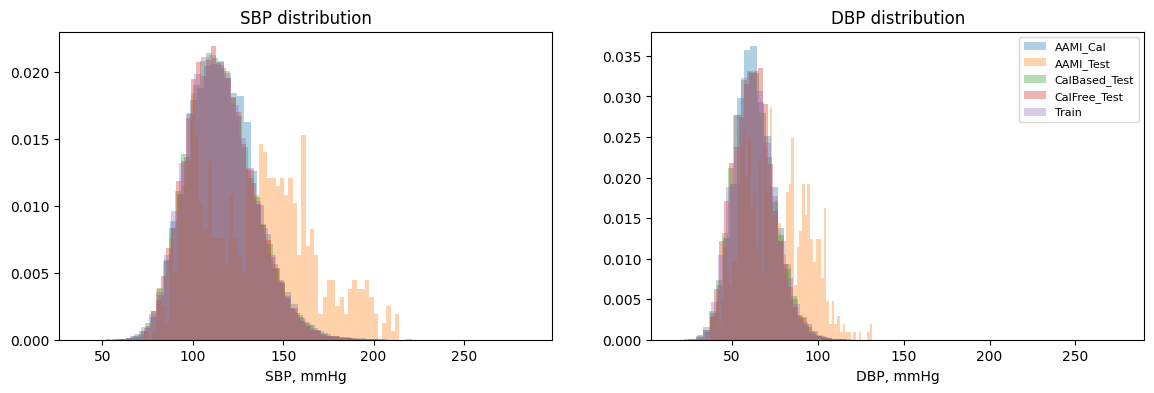

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for file_name, group in meta.groupby("file"):
    label = file_name.replace("VitalDB_", "").replace("_Subset.mat", "")

    axes[0].hist(group["SBP"], bins=60, alpha=0.35, density=True, label=label)
    axes[1].hist(group["DBP"], bins=60, alpha=0.35, density=True, label=label)

axes[0].set_title("SBP distribution")
axes[0].set_xlabel("SBP, mmHg")

axes[1].set_title("DBP distribution")
axes[1].set_xlabel("DBP, mmHg")
axes[1].legend(fontsize=8)

plt.show()

На графиках показано распределение систолического (SBP) и диастолического (DBP) давления для разных подмножеств датасета. Большинство файлов имеют похожее распределение: SBP сконцентрирован примерно около 100-130 мм рт. ст., DBP — около 55-75 мм рт. ст.

Подмножество `AAMI_Test` заметно отличается: на графике виден сдвиг в сторону более высоких значений давления и более выраженный правый хвост. Это означает, что AAMI-тест может быть сложнее для модели, так как он содержит больше случаев с повышенным давлением.

Для обучения модели важно учитывать этот дисбаланс. Если модель обучается в основном на нормальных значениях давления, она может хуже предсказывать редкие высокие значения SBP и DBP.

### Анализ демографических признаков

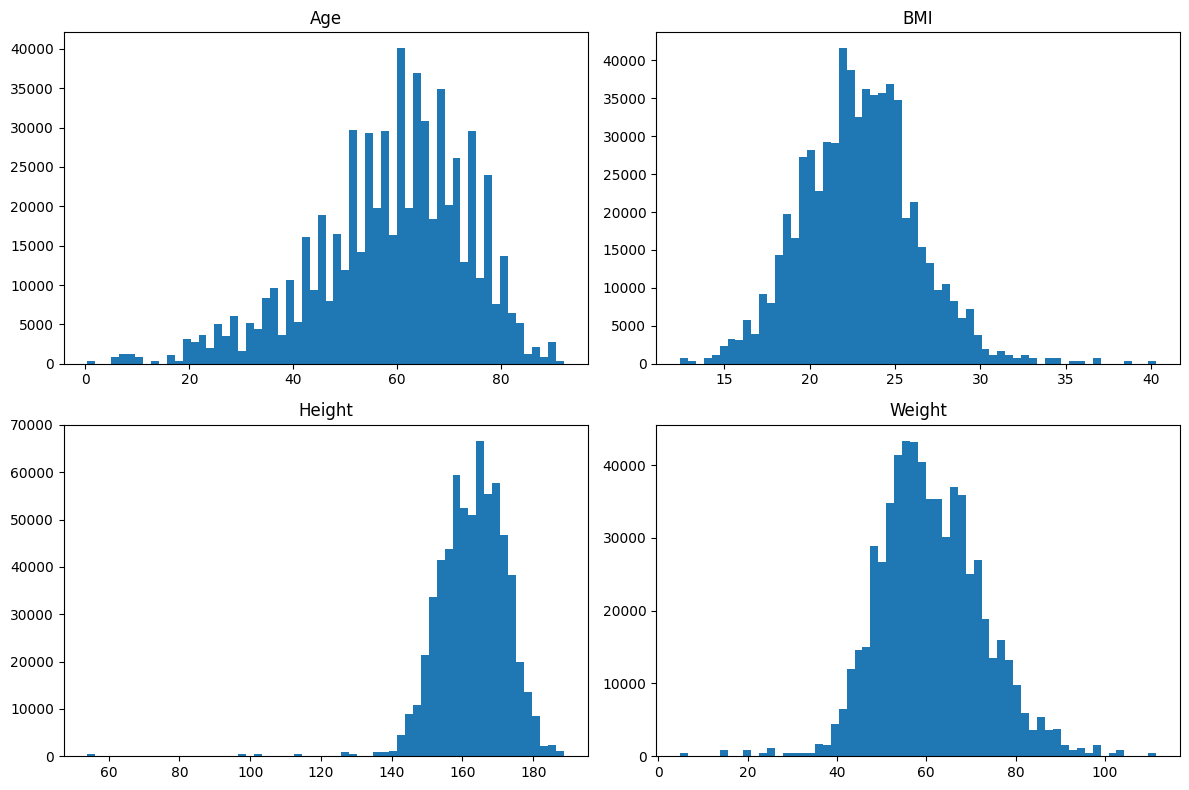

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), ["Age", "BMI", "Height", "Weight"]):
    ax.hist(meta[col], bins=60)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Гистограммы показывают распределение возраста, BMI, роста и веса пациентов. Основная часть пациентов — взрослые и пожилые люди, с пиком возраста примерно в районе 55-75 лет. BMI в основном находится в диапазоне 20-26, что соответствует нормальной массе тела и умеренному превышению.

Рост и вес имеют основную концентрацию около типичных взрослых значений: рост примерно 150-175 см, вес примерно 50-75 кг. При этом видны редкие экстремальные значения, например очень маленький рост и вес.

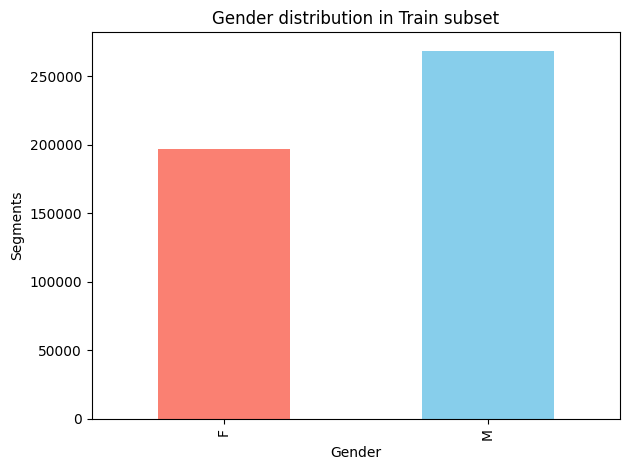

In [9]:
gender = meta.groupby(["file", "Gender"]).size().unstack(fill_value=0)
train_gender = gender.loc['VitalDB_Train_Subset.mat'] 
train_gender.plot(kind='bar', color=['salmon', 'skyblue'])
plt.ylabel('Segments')
plt.title('Gender distribution in Train subset')
plt.tight_layout()
plt.show()

Наблюдается небольшое преобладание мужчин. Соотношение примерно 57% мужчин и 43% женщин. Это умеренный дисбаланс, но не критичный для обучения модели

### Зависимость SBP и DBP

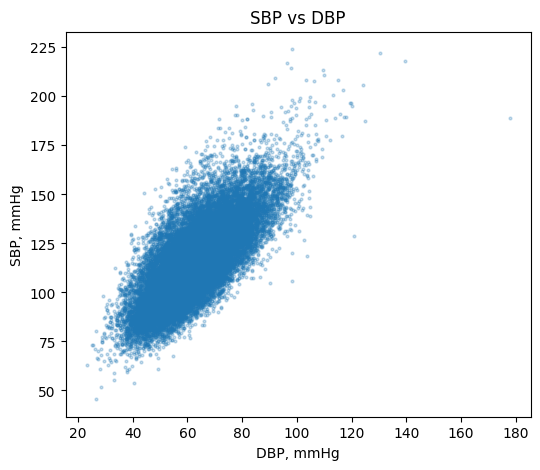

In [10]:
sample = meta.sample(n=min(30000, len(meta)), random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(sample["DBP"], sample["SBP"], s=4, alpha=0.25)
plt.xlabel("DBP, mmHg")
plt.ylabel("SBP, mmHg")
plt.title("SBP vs DBP")
plt.show()

Диаграмма рассеяния показывает положительную связь между SBP и DBP: при увеличении диастолического давления обычно увеличивается и систолическое. Основная масса точек образует плотное облако в диапазоне DBP 45-85 мм рт. ст. и SBP 85-150 мм рт. ст.

In [11]:
subject_counts = (
    meta.groupby(["file", "Subject"])
    .size()
    .reset_index(name="segments")
)

subject_counts.head()

,file,Subject,segments
0,VitalDB_AAMI_Cal_Subset.mat,p000238_1,181
1,VitalDB_AAMI_Cal_Subset.mat,p000241_1,1139
2,VitalDB_AAMI_Cal_Subset.mat,p000284_1,715
3,VitalDB_AAMI_Cal_Subset.mat,p000336_1,824
4,VitalDB_AAMI_Cal_Subset.mat,p000345_1,175


Таблица показывает, сколько 10-секундных сегментов приходится на каждого пациента в каждом файле. Видно, что число сегментов сильно различается: у одних пациентов доступно менее 200 сегментов, у других — более 1000.

### Распределение числа сегментов на пациента


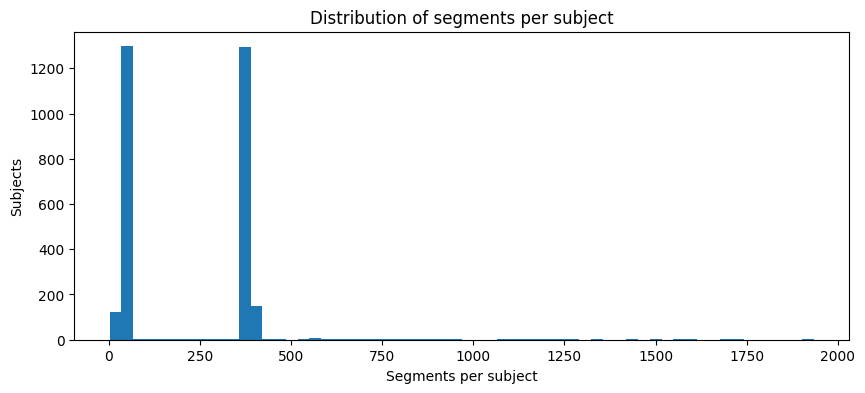

In [12]:
plt.figure(figsize=(10, 4))
plt.hist(subject_counts["segments"], bins=60)
plt.xlabel("Segments per subject")
plt.ylabel("Subjects")
plt.title("Distribution of segments per subject")
plt.show()

На графике показано, сколько 10-секундных сегментов приходится на одного пациента. Распределение неравномерное: большинство пациентов сосредоточено в двух выраженных группах — примерно около 50-70 сегментов и около 370-420 сегментов на пациента. Также есть небольшой хвост пациентов, у которых число сегментов значительно выше и может достигать почти 2000.

### Пример одного 10-секундного сегмента сигналов

In [13]:
path = DATA_DIR / files[0] # VitalDB_Train_Subset
segment_idx = 0

In [14]:
with h5py.File(path, "r") as f:
    signal = np.asarray(f["Subset"]["Signals"][:, :, segment_idx], dtype=float)
    sbp = float(f["Subset"]["SBP"][0, segment_idx])
    dbp = float(f["Subset"]["DBP"][0, segment_idx])
signal.shape, sbp, dbp

((1250, 3), 130.70580747487784, 87.99124350219579)

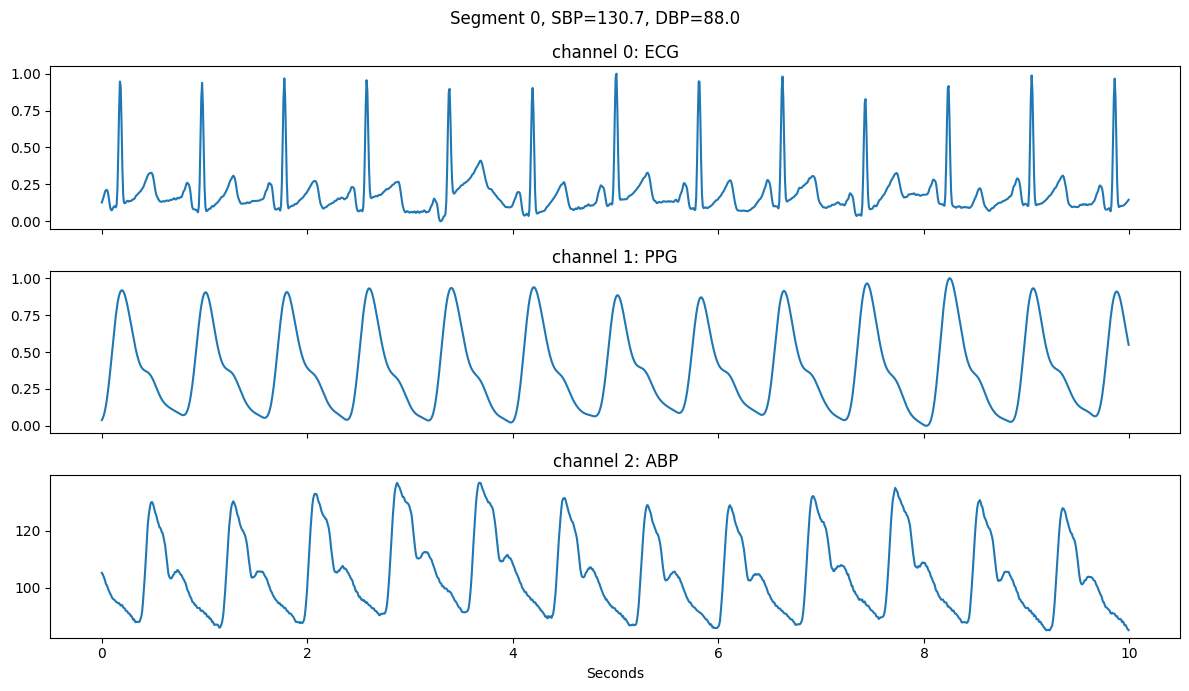

In [15]:
channel_names = ["channel 0: ECG", "channel 1: PPG", "channel 2: ABP"]
t = np.arange(signal.shape[0]) / 125

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for ch in range(3):
    axes[ch].plot(t, signal[:, ch])
    axes[ch].set_title(channel_names[ch])

axes[-1].set_xlabel("Seconds")
plt.suptitle(f"Segment {segment_idx}, SBP={sbp:.1f}, DBP={dbp:.1f}")
plt.tight_layout()
plt.show()

На рисунке показан один сегмент длительностью 10 секунд. 

- Первый график соответствует каналу 0, который похож на ECG-сигнал. На нем видны регулярные резкие пики, соответствующие сердечным сокращениям.
- Второй график — канал 1, PPG-сигнал. Он имеет более сглаженную пульсовую форму и отражает изменение кровенаполнения периферических сосудов.
- Третий график — канал 2, ABP-сигнал, то есть артериальное давление, измеренное инвазивным способом.

Для обучения модели по PPG основным входом будет канал 1. Значения `SBP` и `DBP` используются как целевые переменные. ABP-сигнал полезен как источник эталонного давления

### Корреляция артериального давления с демографией

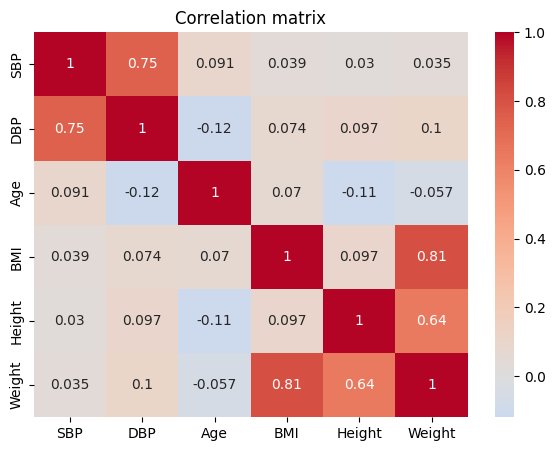

In [16]:
corr_cols = ["SBP", "DBP", "Age", "BMI", "Height", "Weight"]
plt.figure(figsize=(7, 5))
sns.heatmap(meta[corr_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

###  Проверка качества PPG-сигнала

In [17]:
def sample_signal_quality(path, max_rows=5000, ppg_channel=1, seed=42):
    rng = np.random.default_rng(seed)

    with h5py.File(path, "r") as f:
        signals = f["Subset"]["Signals"]
        n = signals.shape[2]
        idxs = np.sort(rng.choice(n, size=min(max_rows, n), replace=False))

        rows = []
        for idx in idxs:
            x = np.asarray(signals[:, ppg_channel, int(idx)], dtype=float)

            rows.append({
                "idx": int(idx),
                "mean": x.mean(),
                "std": x.std(),
                "min": x.min(),
                "max": x.max(),
                "range": x.max() - x.min(),
                "nan_count": np.isnan(x).sum(),
            })

    return pd.DataFrame(rows)

ppg_quality = sample_signal_quality(DATA_DIR / "VitalDB_Train_Subset.mat", max_rows=10000)
ppg_quality.describe()

,idx,mean,std,min,max,range,nan_count
count,10000.000000,10000.000000,10000.000000,10000.0,1.000000e+04,1.000000e+04,10000.0
mean,231642.415700,0.343526,0.285879,0.0,1.000000e+00,1.000000e+00,0.0
std,134014.325562,0.054325,0.029771,0.0,3.881214e-17,3.881214e-17,0.0
min,0.000000,0.181736,0.158098,0.0,1.000000e+00,1.000000e+00,0.0
25%,115147.000000,0.304900,0.267867,0.0,1.000000e+00,1.000000e+00,0.0
50%,230580.500000,0.339350,0.289018,0.0,1.000000e+00,1.000000e+00,0.0
75%,347426.250000,0.378725,0.307527,0.0,1.000000e+00,1.000000e+00,0.0
max,465429.000000,0.625915,0.362142,0.0,1.000000e+00,1.000000e+00,0.0


В таблице приведены базовые статистики качества для 10 000 случайно выбранных PPG-сегментов из обучающего файла.

В выбранной выборке не обнаружено пропущенных значений, PPG-сигнал уже нормализован в диапазоне `[0, 1]`. Среднее значение PPG по сегментам составляет около 0.34, стандартное отклонение — около 0.29. Минимальное стандартное отклонение равно 0.158

## Вывод об анализа датасета

Проведённый анализ показал, что исследуемый набор данных обладает достаточной структурной целостностью. Отсутствие пропущенных значений, наличие предварительно нормализованных сигналов, а также концентрация целевых показателей систолического и диастолического артериального давления в физиологически интерпретируемых диапазонах свидетельствуют о потенциальной применимости данных для задач регрессионного моделирования

Вместе с тем результаты анализа выявили ряд факторов, ограничивающих возможность прямого использования датасета без дополнительной предобработки и контроля качества. К числу наиболее значимых ограничений относятся наличие экстремальных наблюдений по значениям артериального давления и отдельным демографическим характеристикам, неоднородность распределения сегментов между пациентами, а также статистически выраженные различия между отдельными подмножествами данных.

Дополнительным ограничением практического применения является лицензионный статус набора данных. Поскольку датасет распространяется на условиях лицензии, ограничивающей его коммерческое использование, его применение должно рассматриваться преимущественно в исследовательском и образовательном контексте.